# Exploratory Data Analysis — Data Science Salaries Dataset

Este notebook tem como objetivo explorar o dataset de salários em Data Science.

Objetivos da exploração:

- entender a estrutura do dataset
- identificar valores ausentes
- analisar distribuição de salários
- entender relação entre salário e características das vagas
- verificar o relacionamento das caractéristicas conforme o ano da vaga
- identificar possíveis problemas de qualidade nos dados
- gerar insigths iniciais

Dataset: Data Science Salaries (Kaggle)

## Importação das bibliotecas

Importação das bibliotecas necessárias para a realização da análise exploratória.

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Carregamento do dataset

Os dados são carregados a partir do arquivo DataScience_salaries_2025.CSV localizado na pasta `data/raw`.

In [7]:
df = pd.read_csv("../data/raw/DataScience_salaries_2025.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,MI,FT,Research Scientist,208000,USD,208000,US,0,US,M
1,2025,MI,FT,Research Scientist,147000,USD,147000,US,0,US,M
2,2025,SE,FT,Research Scientist,173000,USD,173000,US,0,US,M
3,2025,SE,FT,Research Scientist,117000,USD,117000,US,0,US,M
4,2025,MI,FT,AI Engineer,100000,USD,100000,US,100,US,M


## Estrutura do dataset

Nesta etapa verificamos:

- número de linhas e colunas
- tipos de dados
- possíveis inconsistências

In [8]:
df.shape

(93597, 11)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 93597 entries, 0 to 93596
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           93597 non-null  int64
 1   experience_level    93597 non-null  str  
 2   employment_type     93597 non-null  str  
 3   job_title           93597 non-null  str  
 4   salary              93597 non-null  int64
 5   salary_currency     93597 non-null  str  
 6   salary_in_usd       93597 non-null  int64
 7   employee_residence  93597 non-null  str  
 8   remote_ratio        93597 non-null  int64
 9   company_location    93597 non-null  str  
 10  company_size        93597 non-null  str  
dtypes: int64(4), str(7)
memory usage: 7.9 MB


## Estatísticas descritivas

Aqui analisamos estatísticas básicas das variáveis numéricas, como:

- média
- mediana
- valores mínimos e máximos
- desvio padrão

A coluna `remote_ratio` apresenta valores relevantes apenas nos percentis.

In [10]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,93597.000000,9.359700e+04,93597.000000,93597.000000
mean,2024.086434,1.623541e+05,157547.696774,21.455816
std,0.641449,2.221425e+05,73649.113729,40.954704
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.062600e+05,106250.000000,0.000000
50%,2024.000000,1.470000e+05,146232.000000,0.000000
75%,2024.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


## Verificação de valores ausentes

Valores ausentes podem impactar análises e modelos de Machine Learning.

Nesta etapa identificamos se existem colunas com dados faltantes.

In [11]:
df.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

## Análise de variáveis categóricas

Aqui exploramos variáveis como:

- nível de experiência
- tipo de emprego
- cargo
- localização da empresa e funcionário
- modelo de trabalho
- tipo da moeda

In [12]:
df["experience_level"].value_counts()

experience_level
SE    54645
MI    28140
EN     8849
EX     1963
Name: count, dtype: int64

In [13]:
df["salary_currency"].value_counts()

salary_currency
USD    88796
GBP     2563
EUR     1643
CAD      307
INR       80
PLN       49
CHF       36
BRL       20
AUD       18
SGD       15
PHP       14
JPY       10
TWD        9
HUF        7
DKK        5
TRY        4
NOK        3
CZK        3
MXN        3
ILS        3
ZAR        3
THB        2
SEK        1
NZD        1
HKD        1
CLP        1
Name: count, dtype: int64

In [14]:
df["employee_residence"].value_counts()

employee_residence
US    84290
CA     3415
GB     2662
AU      312
DE      273
      ...  
AS        1
CN        1
DZ        1
IQ        1
JE        1
Name: count, Length: 96, dtype: int64

In [15]:
((df["company_location"].value_counts()).to_frame()).describe()

,count
count,90.000000
mean,1039.966667
std,8891.582667
min,1.000000
25%,3.000000
50%,9.000000
75%,41.000000
max,84347.000000


In [32]:
df["company_location"].value_counts().head(10)

company_location
US    84347
CA     3416
GB     2670
AU      317
DE      282
FR      230
LT      214
ES      207
NL      193
AT      191
Name: count, dtype: int64

In [17]:
df["company_size"].value_counts()

company_size
M    90578
L     2807
S      212
Name: count, dtype: int64

In [18]:
df["employment_type"].value_counts()

employment_type
FT    93090
PT      247
CT      244
FL       16
Name: count, dtype: int64

In [19]:
df["job_title"].nunique()

317

In [20]:
df["remote_ratio"].value_counts()

remote_ratio
0      73366
100    19933
50       298
Name: count, dtype: int64

## Distribuição dos salários

Nesta etapa analisamos a distribuição da variável `salary_in_usd`.

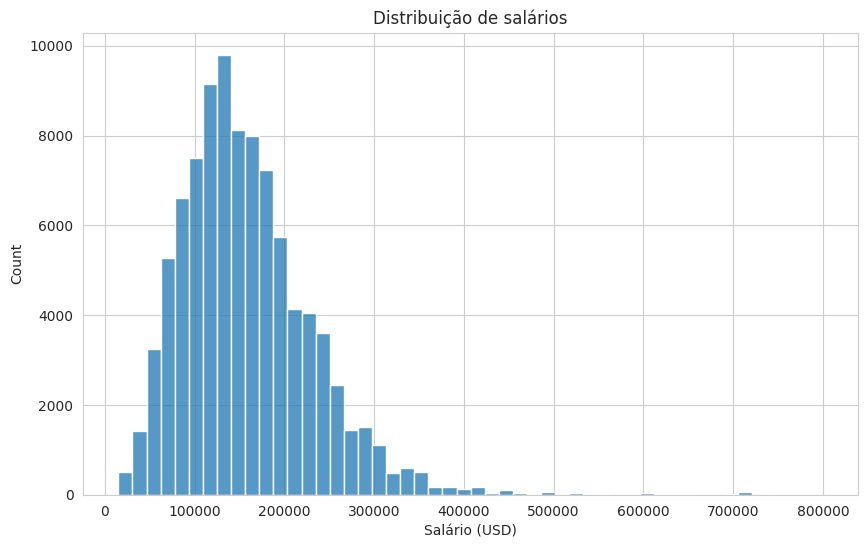

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(df["salary_in_usd"], bins=50)
plt.title("Distribuição de salários")
plt.xlabel("Salário (USD)")
plt.show()

## Salário médio por nível de experiência

Uma hipótese comum é que profissionais mais experientes recebem salários maiores.

Nesta análise verificamos essa relação.

In [22]:
df.groupby("experience_level")["salary_in_usd"].mean().sort_values()

experience_level
EN    100059.640750
MI    143045.893355
SE    172768.485259
EX    200875.546612
Name: salary_in_usd, dtype: float64

<Axes: xlabel='experience_level', ylabel='salary_in_usd'>

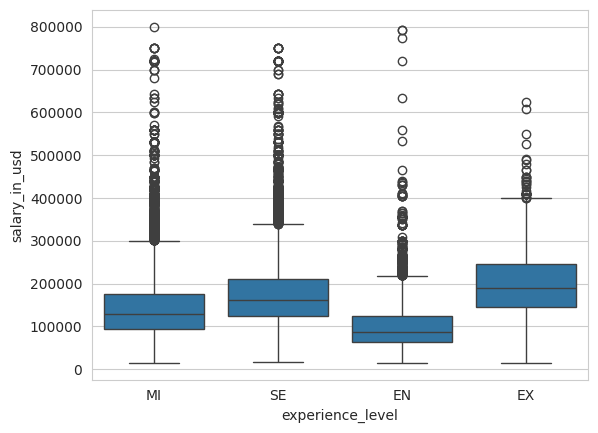

In [23]:
sns.boxplot(x="experience_level", y="salary_in_usd", data=df)

## Salário por tamanho da empresa

Nesta etapa investigamos se empresas maiores pagam salários mais altos.

In [24]:
df.groupby("company_size")["salary_in_usd"].mean()

company_size
L    155469.397221
M    157774.268078
S     88261.900943
Name: salary_in_usd, dtype: float64

<Axes: xlabel='company_size', ylabel='salary_in_usd'>

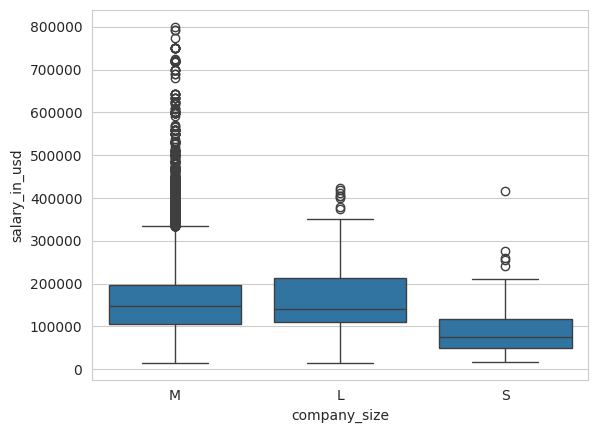

In [25]:
sns.boxplot(x="company_size", y="salary_in_usd", data=df)


## Impacto do trabalho remoto

Analisamos como o nível de trabalho remoto se relaciona com os salários.

<Axes: xlabel='remote_ratio', ylabel='salary_in_usd'>

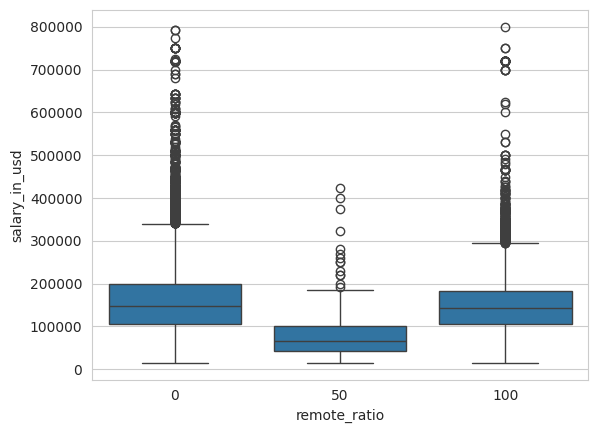

In [26]:
sns.boxplot(x="remote_ratio", y="salary_in_usd", data=df)

## Cargos mais comuns no dataset

In [27]:
df["job_title"].value_counts().head(10)

job_title
Data Scientist               13848
Data Engineer                11323
Software Engineer            10133
Data Analyst                  9081
Machine Learning Engineer     6643
Engineer                      5804
Manager                       3832
Research Scientist            2641
Analyst                       2314
Applied Scientist             1816
Name: count, dtype: int64

<Axes: ylabel='job_title'>

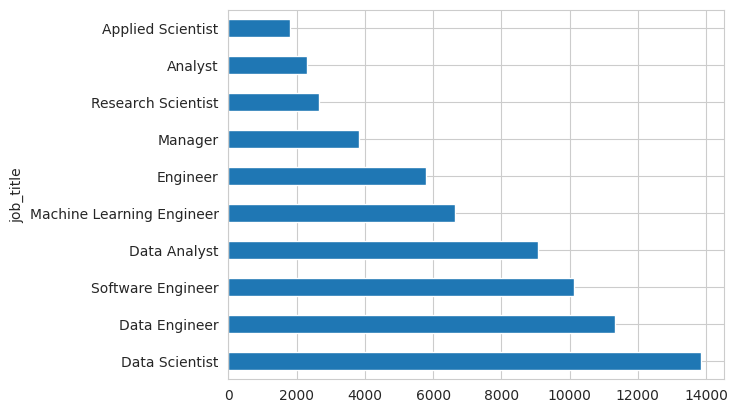

In [28]:
df["job_title"].value_counts().head(10).plot(kind="barh")

## Salários a cada ano

Analisamos a distribuição salarial de acordo com os anos.

<Axes: xlabel='work_year', ylabel='salary_in_usd'>

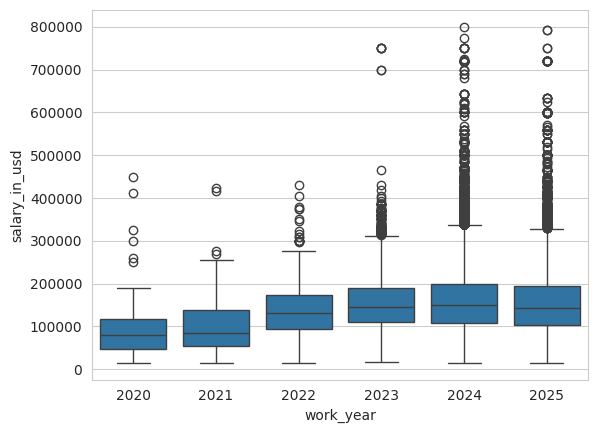

In [29]:
sns.boxplot(x="work_year", y="salary_in_usd", data=df)

## Modalidade de distância por ano

Analisamos a porcentagem do tipo de modalidade a cada ano.

    - 0 = presenciala
    - 50 = híbrido
    - 100 = remoto

<Axes: xlabel='work_year'>

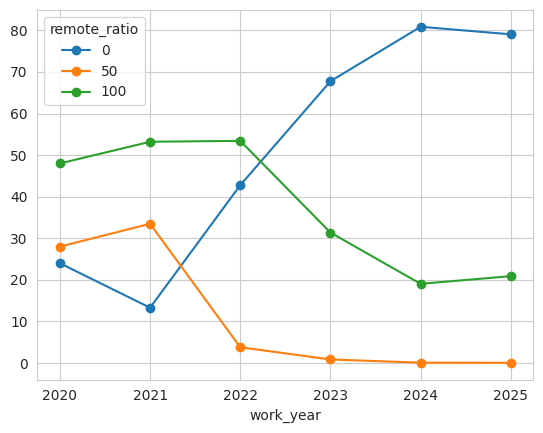

In [30]:
df_remote = pd.pivot_table(
    df,
    index="work_year",
    columns="remote_ratio",
    aggfunc="size"
)
df_remote_pct = df_remote.div(df_remote.sum(axis=1) / 100, axis=0)

df_remote_pct.plot(kind="line", marker="o", )

## Mediana Salarial das 10 Localizações mais recorrentes

Analisamos a mediana salarial das 10 localizações de empresas mais recorrentes no dataframe.

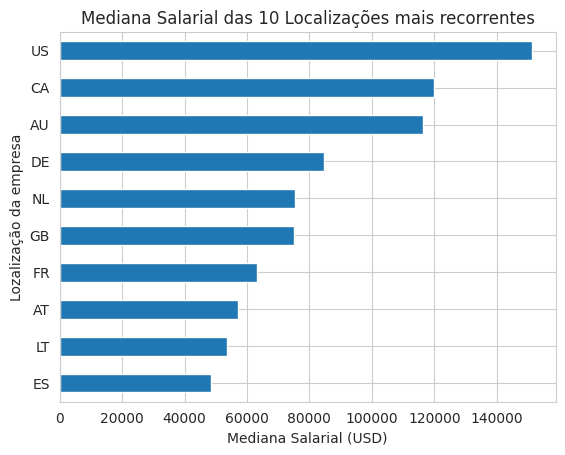

In [31]:
top10_paises = df["company_location"].value_counts().head(10).index

df_top10_paises = df[df["company_location"].isin(top10_paises)]

mediana_salario = (
    df_top10_paises.groupby("company_location")["salary_in_usd"]
    .median()
    .sort_values(ascending=False)
)

mediana_salario.sort_values().plot(kind="barh")

plt.xlabel("Mediana Salarial (USD)")
plt.ylabel("Lozalização da empresa")
plt.title("Mediana Salarial das 10 Localizações mais recorrentes")
plt.show()


## Insights iniciais

A partir da análise exploratória inicial, podemos destacar alguns pontos:

